In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('../..')
import torch
torch.manual_seed(seed=2025)
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import SMMLGraph
import numpy as np
import pandas as pd
import libpysal
from esda.moran import Moran
os.environ['R_HOME'] = 'D:/anaconda3/R-4.0.3'
os.environ['R_USER'] = 'D:/anaconda3/envs/GraphST/Lib/site-packages/rpy2'

In [2]:
adata1 = sc.read_h5ad("E:/Spatial_data/muti_omics/miso_tutorial_data/updated_rna.h5ad")
adata2 = sc.read_h5ad("E:/Spatial_data/muti_omics/miso_tutorial_data/updated_protein.h5ad")
adata1.var_names_make_unique()
adata2.var_names_make_unique()

In [3]:
adata1

AnnData object with n_obs × n_vars = 4194 × 18085
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

In [4]:
# RNA
sc.pp.filter_genes(adata1, min_cells=10)
sc.pp.highly_variable_genes(adata1, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata1, target_sum=1e4)
sc.pp.log1p(adata1)
sc.pp.scale(adata1)

In [ ]:
# Protein
adata2 = SMMLGraph.clr_normalize_each_cell(adata2)
sc.pp.scale(adata2)

In [ ]:
SMMLGraph.Cal_Spatial_Net(adata1, k_cutoff=6, model='KNN')
SMMLGraph.Cal_Spatial_Net(adata2, k_cutoff=6, model='KNN')

In [7]:
print(type(adata2.X))
from scipy import sparse
adata2.X = sparse.csr_matrix(adata2.X)

<class 'numpy.ndarray'>


In [ ]:
SMMLGraph.Cal_Gene_Similarity_Net_KNN(adata1, k_neighbors=5, metric='cosine', verbose=True)
SMMLGraph.Cal_Gene_Similarity_Net_Kmeans(adata1, n_clusters=6, connect_type='intra_cluster_all',metric='cosine')
SMMLGraph.get_intersection_KNN_KMeans(adata1)

SMMLGraph.Cal_Gene_Similarity_Net_KNN(adata2, k_neighbors=5, metric='cosine', verbose=True)
SMMLGraph.Cal_Gene_Similarity_Net_Kmeans(adata2, n_clusters=6, connect_type='intra_cluster_all',metric='cosine')
SMMLGraph.get_intersection_KNN_KMeans(adata2)

In [ ]:
SMMLGraph.merge_local_global_net(adata1, net_key1='Spatial_Net_local', net_key2='Gene_Similarity_Net_Intersection')
SMMLGraph.merge_local_global_net(adata2, net_key1='Spatial_Net_local', net_key2='Gene_Similarity_Net_Intersection')

In [ ]:
adata1,adata2 = SMMLGraph.train_SMMLGraph(adata1,adata2,n_epochs=100)

In [ ]:
adata = SMMLGraph.mclust_R(adata1, used_obsm='SMML-Graph', num_cluster=9)
sc.pp.neighbors(adata1, use_rep='SMML-Graph',n_neighbors=10)
sc.tl.umap(adata1)#把高维的基因表达数据降到 2 维，方便可视化聚类

In [7]:
# 提取原始坐标
x_orig = adata.obsm['spatial'][:, 0].copy()
y_orig = adata.obsm['spatial'][:, 1].copy()

# 逆时针旋转90度：新x = -原y，新y = 原x
adata.obsm['spatial'][:, 0] = -y_orig  # 新X坐标 = -原Y
adata.obsm['spatial'][:, 1] = x_orig   # 新Y坐标 = 原X
adata.obsm['spatial'][:, 1] = -adata.obsm['spatial'][:, 1]

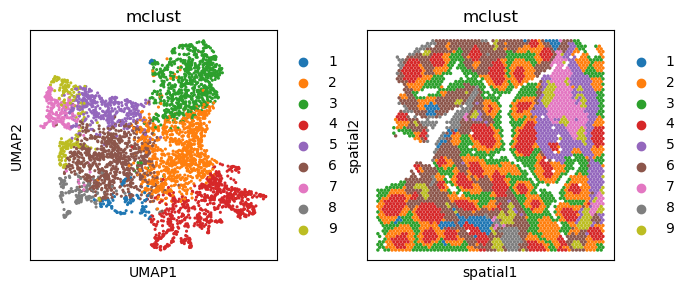

In [14]:
fig, ax_list = plt.subplots(1, 2, figsize=(7, 3))
sc.pl.umap(adata1, ax=ax_list[0],color='mclust', s=20, show=False)
sc.pl.embedding(adata, ax=ax_list[1],basis='spatial', color='mclust', s=25, show=False)
plt.tight_layout(w_pad=0.3)
plt.show()